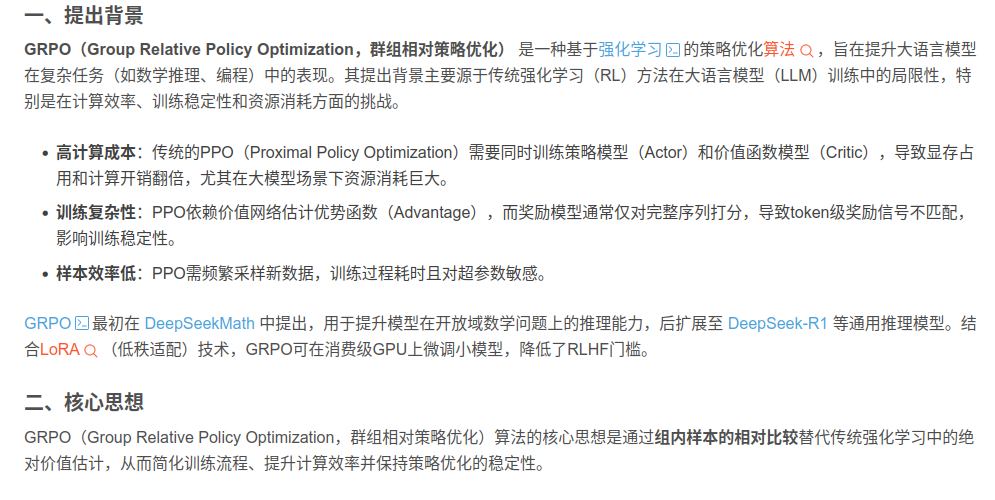

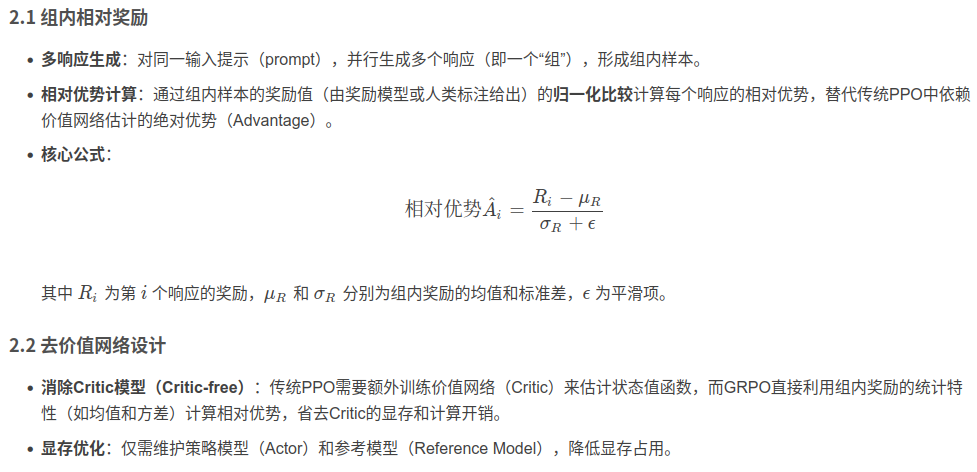

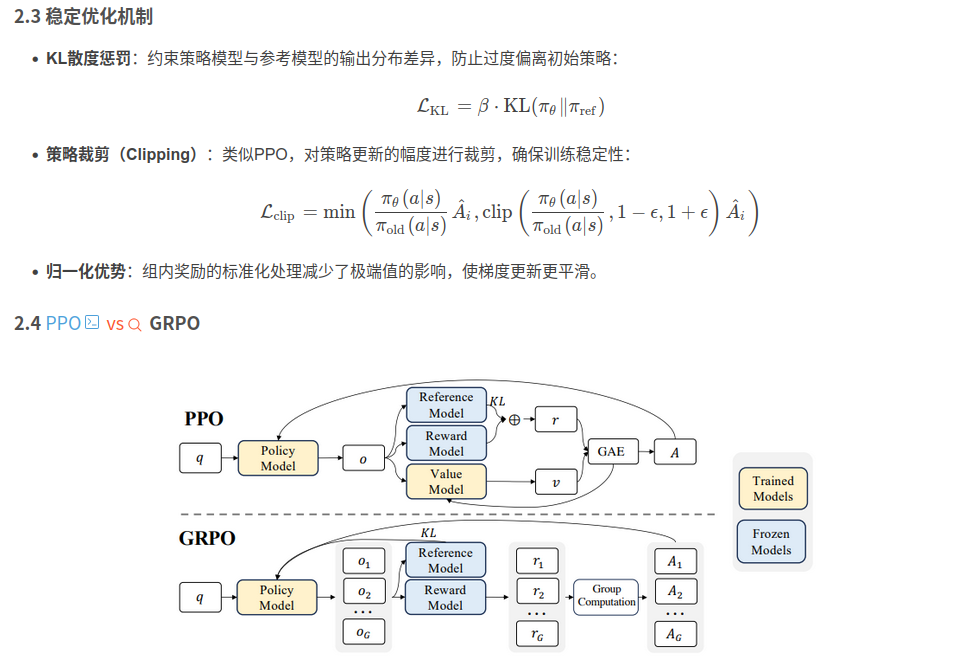

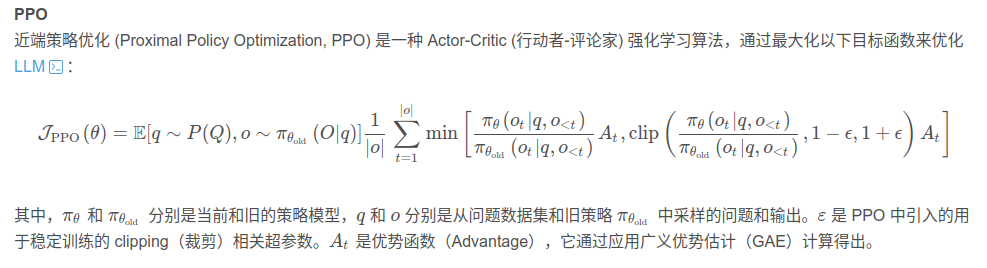

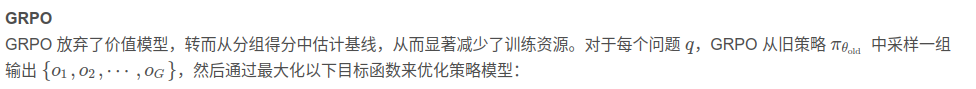

$$
J_{\text{GRPO}}(\theta)=\mathbb{E}_{q\sim P(Q),\{o_i\}_{i=1}^G\sim\pi^{\text{old}}_{\theta}(O\mid q)}\left[\sum_{i=1}^{G}\frac{1}{|o_i|}\sum_{t=1}^{|o_i|}\left(\min\left[\frac{\pi^{\text{old}}_{\theta}(o_{i,t}\mid q, o_i,<t)}{\pi_{\theta}(o_{i,t}\mid q,o_i,<t)}\hat A_{i,t},\,\text{clip}\left(\frac{\pi^{\text{old}}_{\theta}(o_{i,t}\mid q, o_i,<t)}{\pi_{\theta}(o_{i,t}\mid q,o_i,<t)},1-\epsilon,1+\epsilon\right)\hat A_{i,t}\right]\right)-\beta D_{\mathrm{KL}}[\pi_{\theta}\|\pi_{\text{ref}}]\right]
$$

- $q\sim P(Q)$: 查询/场景分布。
- $\{o_i\}_{i=1}^G\sim\pi^{\text{old}}_{\theta}(O\mid q)$: 按旧策略采样回合（或子序列）。
- $o_{i,t}$: 第 $i$ 个轨迹序列的第 $t$ 步动作/操作。
- $\hat A_{i,t}$: 优势估计。
- $\epsilon$ : PPO 剪切超参。
- $\beta$ : KL 惩罚强度。
- $\pi_{\text{ref}}$: 参考策略（可设为旧策略或目标策略）。

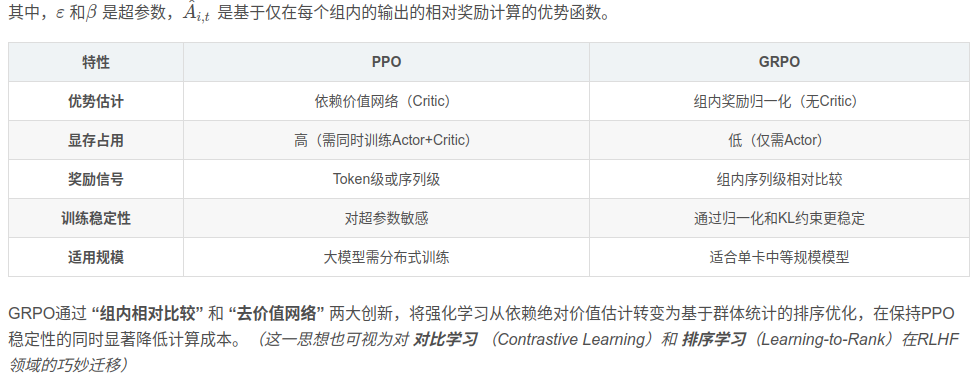

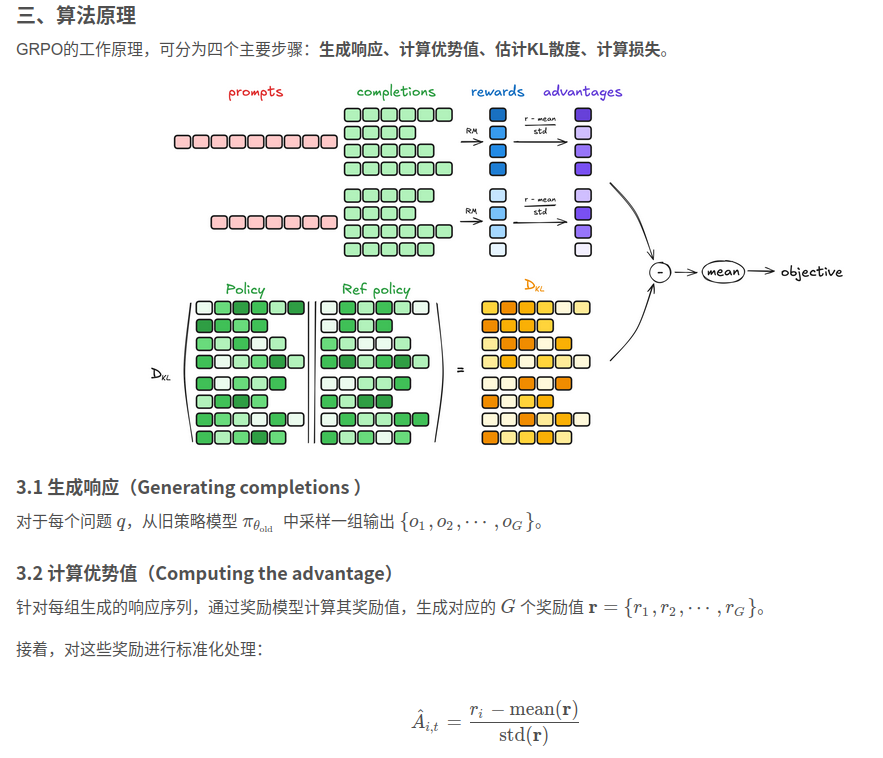

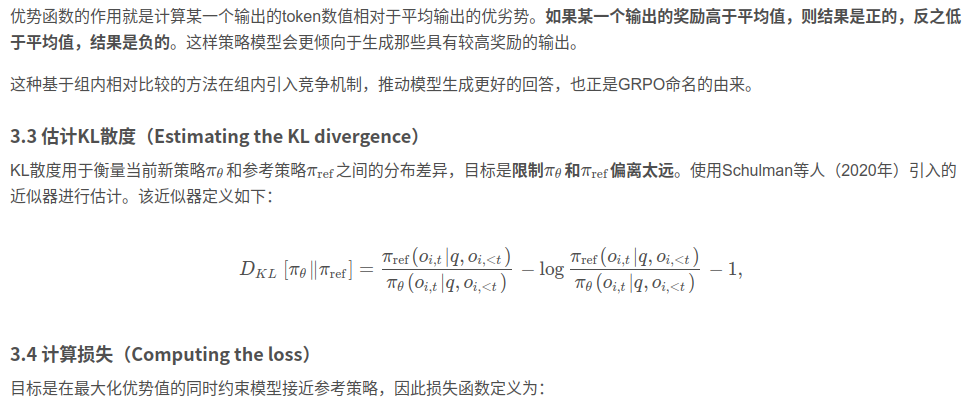

## GRPO 损失函数 L_{GRPO}

GRPO 的损失函数通常是对目标函数取负号（做梯度下降）：

$$
L_{\text{GRPO}}(\theta)= -\frac{1}{G}\sum_{i=1}^{G}\frac{1}{|o_i|}\sum_{t=1}^{|o_i|} \Big[\min\Big(\rho_{i,t}(\theta)\hat A_{i,t},\,\text{clip}(\rho_{i,t}(\theta),1-\epsilon,1+\epsilon)\hat A_{i,t} \Big)\Big] + \beta D_{\mathrm{KL}}[\pi_{\theta} \| \pi_{\text{ref}}]
$$

其中：
- $\rho_{i,t}(\theta)=\frac{\pi^{\text{old}}_{\theta}(o_{i,t}\mid q, o_i,<t)}{\pi_{\theta}(o_{i,t}\mid q, o_i,<t)}$（重要改进：比例系数）
- 第一项为 PPO 风格的裁剪策略梯度项（" clipped policy gradient term "），控制策略更新稳定性。
- 第二项为 KL 散度正则化项，权衡策略与参考策略差异，避免策略离散跳变。

实际训练时，优化目标是最小化该损失函数，立即更新参数 $\theta$。

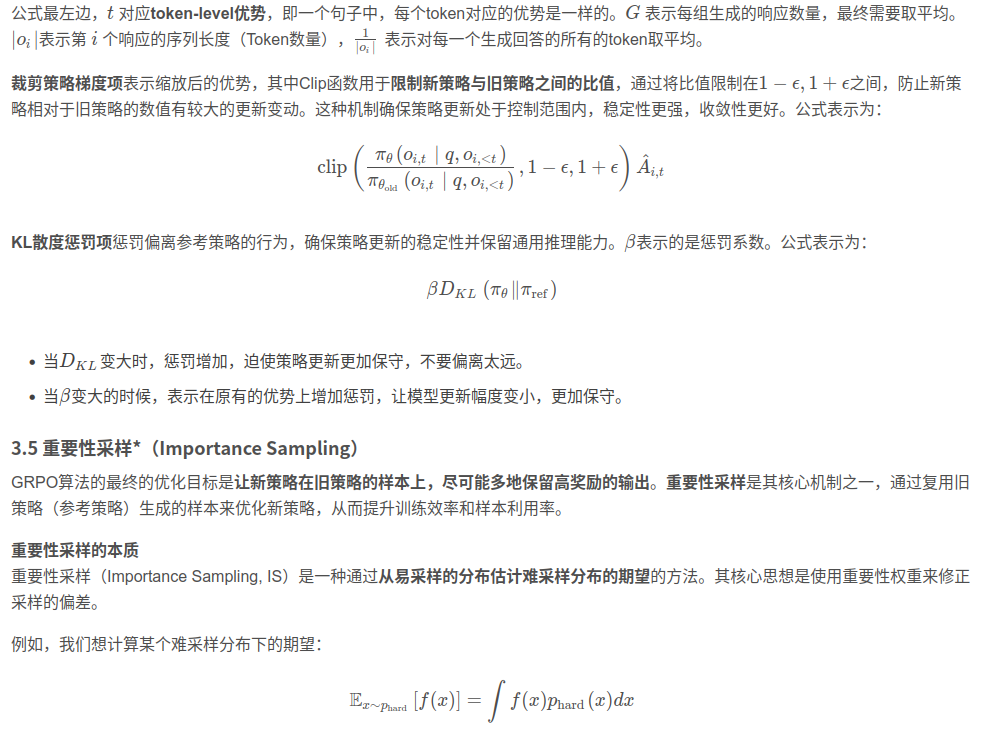

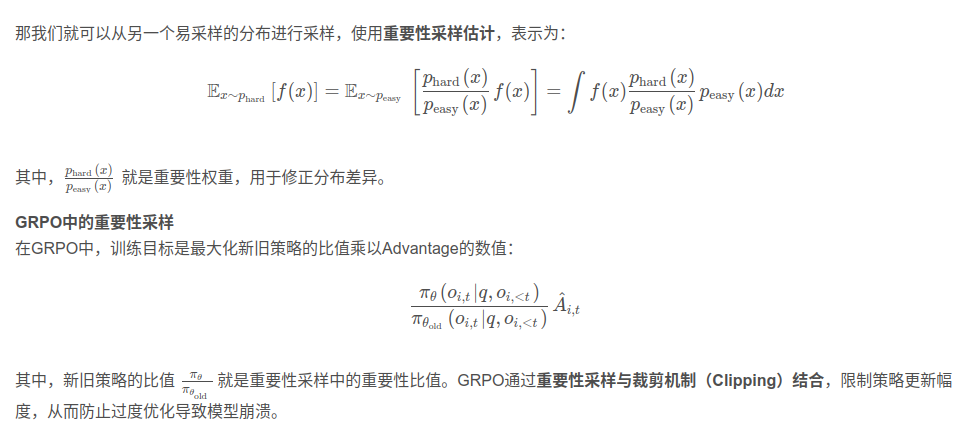